# De-seasonalised Antarctic sea-ice thickness trend

This notebook demonstrates direct remote access to the CSAO Zarr cube and calculates a de-seasonalised Antarctic sea-ice thickness trend from the public dataset. The workflow keeps the data remote, uses lazy `xarray` operations, and only computes the final trend map.

In [5]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

DATA_URL = "https://s3.waw4-1.cloudferro.com/EarthCODE/OSCAssets/polar_cube_datasets/cs+ao/cs_plus.zarr"

SIT_VARIABLE = "SIT_ASD_mean"
SIC_VARIABLE = "sea_ice_conc"
ICE_CONCENTRATION_THRESHOLD = 0.15
MIN_OBSERVATIONS = 24

Open the remote Zarr store. The dataset remains lazy until `.compute()` is called, so the notebook can inspect metadata without downloading the cube.

In [6]:
ds = xr.open_zarr(DATA_URL, consolidated=True)
ds[[SIT_VARIABLE, SIC_VARIABLE]]

<xarray.Dataset> Size: 385MB
Dimensions:       (time: 94, y: 712, x: 712)
Coordinates:
    lat           (y, x) float32 2MB dask.array<chunksize=(356, 356), meta=np.ndarray>
    lon           (y, x) float32 2MB dask.array<chunksize=(356, 356), meta=np.ndarray>
  * time          (time) datetime64[ns] 752B 2013-03-16 ... 2020-12-16
  * x             (x) float32 3kB 6.25e+03 1.875e+04 ... 8.881e+06 8.894e+06
  * y             (y) float32 3kB 8.894e+06 8.881e+06 ... 1.875e+04 6.25e+03
Data variables:
    SIT_ASD_mean  (time, y, x) float32 191MB dask.array<chunksize=(1, 356, 356), meta=np.ndarray>
    sea_ice_conc  (time, y, x) float32 191MB dask.array<chunksize=(1, 356, 356), meta=np.ndarray>
Attributes: (12/55)
    projection:              laea
    lat_ts:                  0.0
    lon_0:                   0
    lat_0:                   -90
    resolution:              c
    pixel_size:              12500
    ...                      ...
    out_file_name:           /work/ALT/odatis/seaice/data/grids_seaice/sh/712...
    start_date:              20170101
    end_date:                20170201
    date_of_creation:        2023-04-01 16:25
    legos_command:           /work/ALT/odatis/seaice/modules/ct_tools/2.18/sc...
    legos_creation_date:     2023-04-01 15:42

Select the two fields used in the trend calculation. Sea-ice concentration is stored as percent and is converted to a 0-1 fraction for masking.

In [7]:
sea_ice_thickness = ds[SIT_VARIABLE].astype("float64")
sea_ice_concentration = (ds[SIC_VARIABLE].astype("float64") / 100.0).clip(0.0, 1.0)

sea_ice_thickness = sea_ice_thickness.where(
    (sea_ice_thickness >= 0.0) & (sea_ice_thickness <= 20.0)
)

In [8]:
ice_mask = sea_ice_concentration >= ICE_CONCENTRATION_THRESHOLD
thickness_in_ice = sea_ice_thickness.where(ice_mask)

thickness_in_ice

<xarray.DataArray 'SIT_ASD_mean' (time: 94, y: 712, x: 712)> Size: 381MB
dask.array<where, shape=(94, 712, 712), dtype=float64, chunksize=(1, 356, 356), chunktype=numpy.ndarray>
Coordinates:
    lat      (y, x) float32 2MB dask.array<chunksize=(356, 356), meta=np.ndarray>
    lon      (y, x) float32 2MB dask.array<chunksize=(356, 356), meta=np.ndarray>
  * time     (time) datetime64[ns] 752B 2013-03-16 2013-04-16 ... 2020-12-16
  * x        (x) float32 3kB 6.25e+03 1.875e+04 ... 8.881e+06 8.894e+06
  * y        (y) float32 3kB 8.894e+06 8.881e+06 ... 1.875e+04 6.25e+03
Attributes:
    long_name:  sea_ice_thickness
    units:      m
    comment:    Sea ice thickness from radar_freeboard where nsidc ice concen...

Remove the mean seasonal cycle by subtracting the monthly climatology at each grid cell.

In [10]:
monthly_climatology = thickness_in_ice.groupby("time.month").mean(
    "time",
    skipna=True,
)

thickness_anomaly = thickness_in_ice.groupby("time.month") - monthly_climatology
thickness_anomaly.name = "de_seasonalised_sea_ice_thickness_anomaly"

Use decimal years as the regression coordinate so the fitted slope is returned in metres per year.

In [11]:
decimal_year = (
    thickness_anomaly["time"].dt.year
    + (thickness_anomaly["time"].dt.dayofyear - 1) / 365.25
)

thickness_anomaly_for_fit = thickness_anomaly.assign_coords(
    decimal_year=("time", decimal_year.data)
).swap_dims({"time": "decimal_year"})

In [12]:
trend_m_per_year = thickness_anomaly_for_fit.polyfit(
    dim="decimal_year",
    deg=1,
    skipna=True,
)["polyfit_coefficients"].sel(degree=1)

valid_observations = thickness_anomaly_for_fit.count("decimal_year")

trend_cm_per_year = (trend_m_per_year * 100.0).where(
    valid_observations >= MIN_OBSERVATIONS
)
trend_cm_per_year.name = "de_seasonalised_thickness_trend_cm_per_year"

Compute the 2D trend map. This is the only step that pulls the full analysis result from the remote store.

In [13]:
trend_cm_per_year = trend_cm_per_year.compute()
trend_cm_per_year

/home/krasen/micromamba/envs/pangeo/lib/python3.13/site-packages/xarray/core/nputils.py:256: RankWarning: Polyfit may be poorly conditioned
  warn_on_deficient_rank(rank, x.shape[1])
/home/krasen/micromamba/envs/pangeo/lib/python3.13/site-packages/xarray/core/nputils.py:256: RankWarning: Polyfit may be poorly conditioned
  warn_on_deficient_rank(rank, x.shape[1])
/home/krasen/micromamba/envs/pangeo/lib/python3.13/site-packages/xarray/core/nputils.py:256: RankWarning: Polyfit may be poorly conditioned
  warn_on_deficient_rank(rank, x.shape[1])
/home/krasen/micromamba/envs/pangeo/lib/python3.13/site-packages/xarray/core/nputils.py:256: RankWarning: Polyfit may be poorly conditioned
  warn_on_deficient_rank(rank, x.shape[1])
/home/krasen/micromamba/envs/pangeo/lib/python3.13/site-packages/xarray/core/nputils.py:256: RankWarning: Polyfit may be poorly conditioned
  warn_on_deficient_rank(rank, x.shape[1])
/home/krasen/micromamba/envs/pangeo/lib/python3.13/site-packages/xarray/core/nputils.

<xarray.DataArray 'de_seasonalised_thickness_trend_cm_per_year' (y: 712, x: 712)> Size: 4MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(712, 712))
Coordinates:
    degree   int64 8B 1
  * y        (y) float32 3kB 8.894e+06 8.881e+06 ... 1.875e+04 6.25e+03
  * x        (x) float32 3kB 6.25e+03 1.875e+04 ... 8.881e+06 8.894e+06
    lat      (y, x) float32 2MB -30.9 -30.99 -31.08 ... -31.08 -30.99 -30.9
    lon      (y, x) float32 2MB -45.0 -44.92 -44.84 -44.76 ... 135.2 135.1 135.0

Plot the de-seasonalised thickness trend on a south polar map.

In [14]:
def plot_thickness_trend_map(ds, trend_cm_per_year, vlim=10):
    fig = plt.figure(figsize=(8, 8))
    ax = plt.axes(projection=ccrs.SouthPolarStereo())

    mesh = ax.pcolormesh(
        ds["lon"],
        ds["lat"],
        trend_cm_per_year,
        transform=ccrs.PlateCarree(),
        shading="auto",
        cmap="RdBu_r",
        vmin=-vlim,
        vmax=vlim,
    )

    ax.set_extent([-180, 180, -90, -50], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, facecolor="0.85", zorder=0)
    ax.coastlines(linewidth=0.8)
    ax.gridlines(draw_labels=False, linewidth=0.5, alpha=0.4)

    cbar = fig.colorbar(mesh, ax=ax, shrink=0.75, pad=0.05)
    cbar.set_label("Thickness trend, cm yr$^{-1}$")

    ax.set_title("De-seasonalised Antarctic sea-ice thickness trend")
    fig.tight_layout()

    return fig, ax

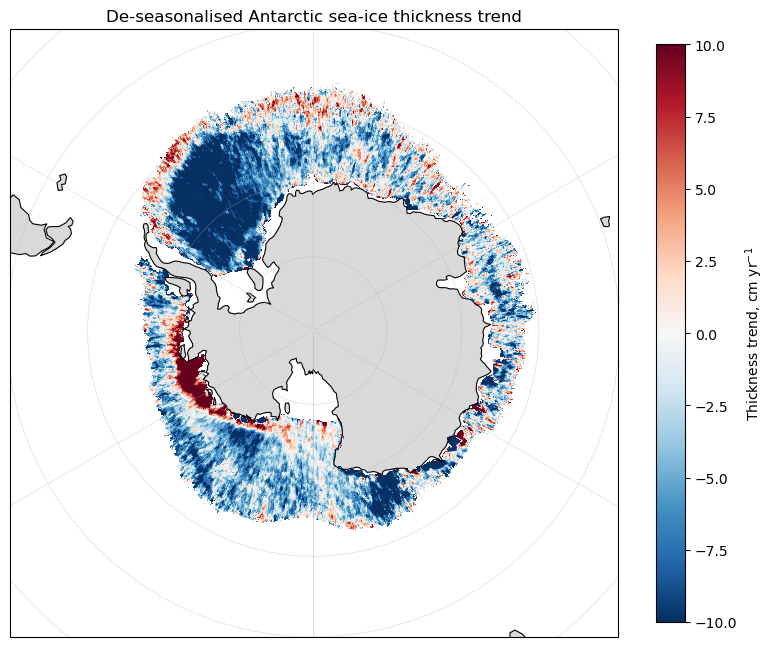

In [15]:
fig, ax = plot_thickness_trend_map(ds, trend_cm_per_year, vlim=10)
plt.show()